# Notebook 01: Construction de la Cohorte & EDA
##
---
**Objectif** : construire la cohorte, définir la cible (Hospitalisation vs Domicile), explorer les données brutes.  

### Fichiers sauvegardés par ce notebook
| Fichier | Chemin | Utilisé par |
|---|---|---|
| `cohort_raw.csv` | `data/processed/` | NB02, NB03, NB04 |
| `cohort_meta.json` | `data/processed/splits/` | NB03, NB04 |
| Figures fig1 à fig6 | `figures/` | - |
| `tab1_flowchart_cohorte.csv` | `results/tables/` | - |

---
## 1. Configuration & Imports

In [1]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
warnings.filterwarnings('ignore')

print('Imports OK')

Imports OK


In [2]:
#  Paramètres globaux 
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
TARGET = 'target'   # 1 = Hospitalisation, 0 = Retour domicile

#  Chemins projet — bloc unifié, identique dans NB01 -> NB08
def _racine_projet(reperes=("data", "results", "models", "notebooks")):
    """Racine = 1er dossier (courant ou parent) contenant un dossier repere."""
    for _p in (Path.cwd(), *Path.cwd().parents):
        if any((_p / _m).is_dir() for _m in reperes):
            return _p
    return Path.cwd()

ROOT_DIR   = _racine_projet()
BASE       = ROOT_DIR / "data"
OUT_DIR    = ROOT_DIR / "data" / "processed"
SPLIT_DIR  = OUT_DIR / "splits"
FIG_DIR    = ROOT_DIR / "figures"
RESULT_DIR = ROOT_DIR / "results"
TABLE_DIR  = RESULT_DIR / "tables"
MODEL_DIR  = ROOT_DIR / "models"
for _d in (OUT_DIR, SPLIT_DIR, FIG_DIR, RESULT_DIR, TABLE_DIR, MODEL_DIR):
    _d.mkdir(parents=True, exist_ok=True)

#  Style graphiques 
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize']    = (12, 5)
plt.rcParams['font.family']       = 'DejaVu Sans'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

BLEU   = '#2E5F8A'
ROUGE  = '#C0392B'
ORANGE = '#E67E22'
BLEU_C = '#A8C8E8'

#print(f'OUT_DIR  : {OUT_DIR.resolve()}')
#print(f'FIG_DIR  : {FIG_DIR.resolve()}')

---
## 2. Chargement des tables MIMIC-IV ED

In [3]:
#  Helpers de lecture 
def read_csv_checked(path, **kwargs):
    """Lecture obligatoire  lève une erreur si le fichier est absent."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f'Fichier absent : {path}')
    return pd.read_csv(path, low_memory=False, **kwargs)

# Chargement 
df_stays      = pd.read_csv(BASE / 'edstays.csv.gz')
df_triage     = pd.read_csv(BASE / 'triage.csv.gz')
df_patients   = pd.read_csv(BASE / 'patients.csv.gz')
df_diagnoses  = pd.read_csv(BASE / 'diagnoses_icd.csv.gz')
df_admissions = pd.read_csv(
    BASE / 'admissions.csv.gz',
    usecols=['subject_id', 'hadm_id', 'admittime', 'dischtime'],
    low_memory=False
)
print('Chargement des tables terminé')

Chargement des tables terminé


In [4]:
# Dates utilisées ensuite pour l'anti-leakage temporel.
df_stays['intime']          = pd.to_datetime(df_stays['intime'], errors='coerce')
df_admissions['admittime']  = pd.to_datetime(df_admissions['admittime'], errors='coerce')
df_admissions['dischtime']  = pd.to_datetime(df_admissions['dischtime'], errors='coerce')

In [5]:
display(df_stays.head())
print(f'edstays    : {len(df_stays):,} lignes × {df_stays.shape[1]} colonnes')

,subject_id,hadm_id,stay_id,intime,outtime,gender,race,arrival_transport,disposition
0,10000032,22595853.0,33258284,2180-05-06 19:17:00,2180-05-06 23:30:00,F,WHITE,AMBULANCE,ADMITTED
1,10000032,22841357.0,38112554,2180-06-26 15:54:00,2180-06-26 21:31:00,F,WHITE,AMBULANCE,ADMITTED
2,10000032,25742920.0,35968195,2180-08-05 20:58:00,2180-08-06 01:44:00,F,WHITE,AMBULANCE,ADMITTED
3,10000032,29079034.0,32952584,2180-07-22 16:24:00,2180-07-23 05:54:00,F,WHITE,AMBULANCE,HOME
4,10000032,29079034.0,39399961,2180-07-23 05:54:00,2180-07-23 14:00:00,F,WHITE,AMBULANCE,ADMITTED


edstays    : 425,087 lignes × 9 colonnes


In [6]:
display(df_triage.head())
print(f'triage     : {len(df_triage):,} lignes × {df_triage.shape[1]} colonnes')

,subject_id,stay_id,temperature,heartrate,resprate,o2sat,sbp,dbp,pain,acuity,chiefcomplaint
0,10000032,32952584,97.8,87.0,14.0,97.0,71.0,43.0,7,2.0,Hypotension
1,10000032,33258284,98.4,70.0,16.0,97.0,106.0,63.0,0,3.0,"Abd pain, Abdominal distention"
2,10000032,35968195,99.4,105.0,18.0,96.0,106.0,57.0,10,3.0,"n/v/d, Abd pain"
3,10000032,38112554,98.9,88.0,18.0,97.0,116.0,88.0,10,3.0,Abdominal distention
4,10000032,39399961,98.7,77.0,16.0,98.0,96.0,50.0,13,2.0,"Abdominal distention, Abd pain, LETHAGIC"


triage     : 425,087 lignes × 11 colonnes


In [7]:
display(df_patients.head())
print(f'patients   : {len(df_patients):,} lignes × {df_patients.shape[1]} colonnes')

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10000032,F,52,2180,2014 - 2016,2180-09-09
1,10000048,F,23,2126,2008 - 2010,NaN
2,10000058,F,33,2168,2020 - 2022,NaN
3,10000068,F,19,2160,2008 - 2010,NaN
4,10000084,M,72,2160,2017 - 2019,2161-02-13


patients   : 364,627 lignes × 6 colonnes


In [8]:
display(df_diagnoses.head())
print(f'diagnoses  : {len(df_diagnoses):,} lignes × {df_diagnoses.shape[1]} colonnes')

,subject_id,hadm_id,seq_num,icd_code,icd_version
0,10000032,22595853,1,5723,9
1,10000032,22595853,2,78959,9
2,10000032,22595853,3,5715,9
3,10000032,22595853,4,07070,9
4,10000032,22595853,5,496,9


diagnoses  : 6,364,488 lignes × 5 colonnes


In [9]:
display(df_admissions.head())
print(f'admissions : {len(df_admissions):,} lignes × {df_admissions.shape[1]} colonnes')

,subject_id,hadm_id,admittime,dischtime
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00
1,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00
2,10000032,25742920,2180-08-05 23:44:00,2180-08-07 17:50:00
3,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00
4,10000068,25022803,2160-03-03 23:16:00,2160-03-04 06:26:00


admissions : 546,028 lignes × 4 colonnes


In [10]:
# Calcul des comorbidités: Score de comorbidité de type Charlson + flags binaires 
# Référence : Charlson ME et al., J Chronic Dis 1987;40(5):373-383
# Mappings ICD-10 : Quan H et al., Med Care 2005;43(11):1130-1139
# Calcul cumulatif par stay_id, uniquement avec les
# diagnostics d'hospitalisations terminées AVANT l'arrivée aux urgences.

import gc

ICD10_PATTERNS = {
    'cm_dm_sans_complic':    (['E10','E11','E13'],                         1),
    'cm_dm_avec_complic':    (['E102','E103','E104','E105','E106',
                               'E112','E113','E114','E115','E116'],        2),
    'cm_insuffisance_card':  (['I50'],                                     1),
    'cm_bpco':               (['J41','J42','J43','J44'],                   1),
    'cm_insuffisance_renale':(['N18','N19'],                               2),
    'cm_cancer':             (['C0','C1','C2','C3','C4',
                               'C5','C6','C7','C8','C9'],                 2),
    'cm_cancer_meta':        (['C77','C78','C79','C80'],                   6),
    'cm_infarctus':          (['I21','I22','I25'],                         1),
    'cm_avc':                (['I63','I64','G45'],                         1),
    'cm_demence':            (['F00','F01','F02','F03','G30'],              1),
    'cm_maladie_foie':       (['K70','K73','K74'],                         1),
    'cm_vih_sida':               (['B20','B21','B22','B24'],                   6),
}

ICD9_PATTERNS = {
    'cm_dm_sans_complic':    (['2500'],                          1),
    'cm_dm_avec_complic':    (['2501','2502','2503'],             2),
    'cm_insuffisance_card':  (['428'],                            1),
    'cm_bpco':               (['491','492','493','496'],          1),
    'cm_insuffisance_renale':(['585','586'],                       2),
    'cm_cancer':             (['14','15','16','17','18','19',
                               '20','21','22','23'],              2),
    'cm_cancer_meta':        (['196','197','198','199'],          6),
    'cm_infarctus':          (['410','412'],                      1),
    'cm_avc':                (['430','431','432','433','434',
                               '435','436','437','438'],          1),
    'cm_demence':            (['290','2941'],                     1),
    'cm_maladie_foie':       (['571'],                            1),
    'cm_vih_sida':               (['042','043','044'],                6),
}

cm_cols_list = list(ICD10_PATTERNS.keys())
DIAG_AVAILABLE = (
    'df_diagnoses' in dir()
    and df_diagnoses is not None
    and len(df_diagnoses) > 0
    and 'hadm_id' in df_diagnoses.columns
)

if DIAG_AVAILABLE:
    # 1) Diagnostics hospitaliers + date de sortie de l'hospitalisation.
    diag = df_diagnoses[['subject_id', 'hadm_id', 'icd_code', 'icd_version']].copy()
    diag = diag.merge(
        df_admissions[['subject_id', 'hadm_id', 'dischtime']],
        on=['subject_id', 'hadm_id'],
        how='left'
    )
    diag = diag[diag['dischtime'].notna()].copy()
    diag['dischtime'] = pd.to_datetime(diag['dischtime'], errors='coerce')
    diag['icd_code'] = (
        diag['icd_code'].astype(str)
        .str.upper()
        .str.replace('.', '', regex=False)
    )

    # 2) Flags Charlson par ligne de diagnostic.
    for col in cm_cols_list:
        diag[col] = 0

    mask10 = diag['icd_version'].eq(10)
    mask09 = diag['icd_version'].eq(9)

    for col, (prefixes, _) in ICD10_PATTERNS.items():
        pattern = '|'.join(f'^{p}' for p in prefixes)
        diag.loc[mask10, col] = diag.loc[mask10, 'icd_code'].str.match(pattern).astype('int8')

    for col, (prefixes, _) in ICD9_PATTERNS.items():
        pattern = '|'.join(f'^{p}' for p in prefixes)
        diag.loc[mask09, col] = diag.loc[mask09, 'icd_code'].str.match(pattern).astype('int8')

    # 3) Agrégation par hospitalisation, puis cumul temporel par patient.
    adm_cm = (
        diag.groupby(['subject_id', 'hadm_id', 'dischtime'], as_index=False)[cm_cols_list]
        .max()
        .sort_values(['subject_id', 'dischtime'])
    )
    del diag; gc.collect()

    # Cumul des antécédents : à chaque date de sortie, on connaît tout ce qui était documenté jusque-là.
    adm_cm[cm_cols_list] = adm_cm.groupby('subject_id')[cm_cols_list].cummax()

    # 4) Pour chaque séjour ED, récupérer le dernier état connu AVANT intime.
    stays_for_cm = (
        df_stays[['subject_id', 'stay_id', 'intime']]
        .drop_duplicates('stay_id')
        .copy()
    )
    stays_for_cm['intime'] = pd.to_datetime(stays_for_cm['intime'], errors='coerce')

    # merge_asof : les deux tables doivent être triées par la clé temporelle.
    stays_sorted = stays_for_cm.sort_values(['intime', 'subject_id'])
    adm_sorted   = adm_cm.sort_values(['dischtime', 'subject_id'])

    cm_asof = pd.merge_asof(
        stays_sorted,
        adm_sorted,
        left_on='intime',
        right_on='dischtime',
        by='subject_id',
        direction='backward',
        allow_exact_matches=False
    )

    df_comorbidities = cm_asof[['stay_id'] + cm_cols_list].copy()
    df_comorbidities[cm_cols_list] = df_comorbidities[cm_cols_list].fillna(0).astype('int8')

    # Exclusions mutuelles après cumul.
    df_comorbidities.loc[df_comorbidities['cm_dm_avec_complic'] == 1, 'cm_dm_sans_complic'] = 0
    df_comorbidities.loc[df_comorbidities['cm_cancer_meta'] == 1, 'cm_cancer'] = 0

    # Score de comorbidité de type Charlson pondéré.
    # Le mapping utilisé reste volontairement synthétique ; l'alias
    # charlson_score_simplifie est utilisé dans les modèles et la rédaction.
    weights = pd.Series({col: weight for col, (_, weight) in ICD10_PATTERNS.items()})
    df_comorbidities['charlson_score'] = (
        df_comorbidities[cm_cols_list].multiply(weights, axis=1).sum(axis=1).astype(int)
    )
    df_comorbidities['charlson_score_simplifie'] = df_comorbidities['charlson_score']

    print(f'Comorbidités calculées : {len(df_comorbidities):,} séjours (par stay_id)')
    print('Anti-leakage ICD : uniquement diagnostics avec dischtime < intime')
    print(f'Séjours avec Charlson > 0 : {(df_comorbidities["charlson_score"] > 0).sum():,} '
          f'({(df_comorbidities["charlson_score"] > 0).mean()*100:.1f}%)')

    for col in cm_cols_list:
        pct = df_comorbidities[col].mean() * 100
        print(f'  {col:<30} : {pct:.1f}%')

else:
    df_comorbidities = pd.DataFrame(columns=['stay_id', 'charlson_score', 'charlson_score_simplifie'] + cm_cols_list)
    print('Comorbidités non calculées — diagnostics/hadm_id indisponibles')


Comorbidités calculées : 425,087 séjours (par stay_id)
Anti-leakage ICD : uniquement diagnostics avec dischtime < intime
Séjours avec Charlson > 0 : 146,785 (34.5%)
  cm_dm_sans_complic             : 9.7%
  cm_dm_avec_complic             : 4.7%
  cm_insuffisance_card           : 9.3%
  cm_bpco                        : 12.1%
  cm_insuffisance_renale         : 10.0%
  cm_cancer                      : 8.5%
  cm_cancer_meta                 : 2.6%
  cm_infarctus                   : 8.1%
  cm_avc                         : 4.5%
  cm_demence                     : 1.7%
  cm_maladie_foie                : 4.7%
  cm_vih_sida                    : 1.0%


### Note méthodologique:Le score de comorbidité de type Charlson

Le score utilisé dans ce projet est nommé `charlson_score_simplifie` dans les modèles. Il reprend une logique de pondération de type Charlson à partir des diagnostics antérieurs disponibles, mais le mapping ICD reste synthétique et ne doit pas être présenté comme un Charlson complet validé. La colonne historique `charlson_score` peut être conservée comme alias de compatibilité, mais la rédaction doit privilégier l'expression **score de comorbidité de type Charlson simplifié**.


In [11]:
# Vérification des comorbidités calculées 
print(f'df_comorbidities : {df_comorbidities.shape[0]:,} lignes × {df_comorbidities.shape[1]} colonnes')
display(df_comorbidities.head(3))

df_comorbidities : 425,087 lignes × 15 colonnes


,stay_id,cm_dm_sans_complic,cm_dm_avec_complic,cm_insuffisance_card,cm_bpco,cm_insuffisance_renale,cm_cancer,cm_cancer_meta,cm_infarctus,cm_avc,cm_demence,cm_maladie_foie,cm_vih_sida,charlson_score,charlson_score_simplifie
0,35341790,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,39042378,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,35220003,0,0,0,0,0,0,0,0,0,0,0,0,0,0


---
## 3. Création de la cible & Filtrage des dispositions

In [12]:
# Exploration des types de sortie disponibles
print('=== Issue des patients après leur passage aux urgences ===')
print(df_stays['disposition'].value_counts())
print()

n_avant = len(df_stays)

# On garde uniquement ADMITTED et HOME donc issue certaine.
# .copy() évite les avertissements SettingWithCopy et sécurise la création de la cible.
df_stays_filt = df_stays[df_stays['disposition'].isin(['ADMITTED', 'HOME'])].copy()

# Exclusion : Expired, Left without being seen, etc.
df_stays_filt[TARGET] = (df_stays_filt['disposition'] == 'ADMITTED').astype(int)

df_stays_final = df_stays_filt.copy()

display(df_stays_final.head())

print(f'Séjour total aux urgences : {n_avant:,}')
print(f'Séjours rétenus   : {len(df_stays_final):,}  (exclus : {n_avant - len(df_stays_final):,})')

print(f'Taux hospitalisation  : {df_stays_final[TARGET].mean()*100:.1f}%')

=== Issue des patients après leur passage aux urgences ===
disposition
HOME                           241632
ADMITTED                       158010
TRANSFER                         7025
LEFT WITHOUT BEING SEEN          6155
ELOPED                           5710
OTHER                            4297
LEFT AGAINST MEDICAL ADVICE      1881
EXPIRED                           377
Name: count, dtype: int64



,subject_id,hadm_id,stay_id,intime,outtime,gender,race,arrival_transport,disposition,target
0,10000032,22595853.0,33258284,2180-05-06 19:17:00,2180-05-06 23:30:00,F,WHITE,AMBULANCE,ADMITTED,1
1,10000032,22841357.0,38112554,2180-06-26 15:54:00,2180-06-26 21:31:00,F,WHITE,AMBULANCE,ADMITTED,1
2,10000032,25742920.0,35968195,2180-08-05 20:58:00,2180-08-06 01:44:00,F,WHITE,AMBULANCE,ADMITTED,1
3,10000032,29079034.0,32952584,2180-07-22 16:24:00,2180-07-23 05:54:00,F,WHITE,AMBULANCE,HOME,0
4,10000032,29079034.0,39399961,2180-07-23 05:54:00,2180-07-23 14:00:00,F,WHITE,AMBULANCE,ADMITTED,1


Séjour total aux urgences : 425,087
Séjours rétenus   : 399,642  (exclus : 25,445)
Taux hospitalisation  : 39.5%


---
## 4. Fusion de la base de départ

In [13]:
# Conversion des dates avant fusion
for df_tmp, cols in [
    (df_stays_final, ['intime', 'outtime']),
]:
    for c in cols:
        if c in df_tmp.columns:
            df_tmp[c] = pd.to_datetime(df_tmp[c], errors='coerce')

# Fusion principale : edstays + triage + patients
df = df_stays_final.merge(df_triage, on=['subject_id', 'stay_id'], how='left', suffixes=('', '_triage'))

# Variables patients. anchor_year permet d'approcher l'âge au passage ED.
patients_cols = ['subject_id', 'anchor_age', 'anchor_year_group']
if 'anchor_year' in df_patients.columns:
    patients_cols.append('anchor_year')
if 'gender' not in df.columns and 'gender' in df_patients.columns:
    patients_cols.append('gender')
patients_cols = list(dict.fromkeys([c for c in patients_cols if c in df_patients.columns]))
df = df.merge(df_patients[patients_cols], on='subject_id', how='left')

# Variables temporelles
df['duree_ed_h']  = (df['outtime'] - df['intime']).dt.total_seconds() / 3600
df['hour']        = df['intime'].dt.hour
# is_night et is_weekend supprimés (décision méthodologique : variables contextuelles
# non transposables hors MIMIC-IV )
df['day_of_week'] = df['intime'].dt.dayofweek  # variable contextuelle utilisée dans les modèles

# Âge approximatif au moment du passage aux urgences.
# Si anchor_year est disponible : age_ed = anchor_age + (année du passage - anchor_year).
# Sinon, age_ed reprend anchor_age et la limite doit être indiquée dans la méthode.
df['intime_year'] = df['intime'].dt.year
if {'anchor_age', 'anchor_year'}.issubset(df.columns):
    df['age_ed'] = pd.to_numeric(df['anchor_age'], errors='coerce') + (
        pd.to_numeric(df['intime_year'], errors='coerce') - pd.to_numeric(df['anchor_year'], errors='coerce')
    )
    df['age_ed'] = df['age_ed'].clip(lower=0, upper=120)
    print('age_ed calculé à partir de anchor_age, anchor_year et intime_year.')
else:
    df['age_ed'] = pd.to_numeric(df.get('anchor_age'), errors='coerce')
    print('anchor_year absent : age_ed reprend anchor_age. Mentionner cette approximation dans la méthode.')

AGE_COL = 'age_ed' if 'age_ed' in df.columns else 'anchor_age'

# Nettoyage des colonnes dupliquées (_x / _y)
for col in list(df.columns):
    if col.endswith('_x'):
        base  = col[:-2]
        col_y = base + '_y'
        if col_y in df.columns:
            df[base] = df[col].combine_first(df[col_y])
            df = df.drop(columns=[col, col_y])
            print(f'Fusion {col} + {col_y} → {base}')

print(f'\nBase fusionnée : {df.shape[0]:,} séjours × {df.shape[1]} colonnes')


age_ed calculé à partir de anchor_age, anchor_year et intime_year.

Base fusionnée : 399,642 séjours × 27 colonnes


In [14]:
pd.set_option('display.max_columns', None)
df.head()

,subject_id,hadm_id,stay_id,intime,outtime,gender,race,arrival_transport,disposition,target,temperature,heartrate,resprate,o2sat,sbp,dbp,pain,acuity,chiefcomplaint,anchor_age,anchor_year_group,anchor_year,duree_ed_h,hour,day_of_week,intime_year,age_ed
0,10000032,22595853.0,33258284,2180-05-06 19:17:00,2180-05-06 23:30:00,F,WHITE,AMBULANCE,ADMITTED,1,98.4,70.0,16.0,97.0,106.0,63.0,0,3.0,"Abd pain, Abdominal distention",52.0,2014 - 2016,2180.0,4.216667,19,5,2180,52.0
1,10000032,22841357.0,38112554,2180-06-26 15:54:00,2180-06-26 21:31:00,F,WHITE,AMBULANCE,ADMITTED,1,98.9,88.0,18.0,97.0,116.0,88.0,10,3.0,Abdominal distention,52.0,2014 - 2016,2180.0,5.616667,15,0,2180,52.0
2,10000032,25742920.0,35968195,2180-08-05 20:58:00,2180-08-06 01:44:00,F,WHITE,AMBULANCE,ADMITTED,1,99.4,105.0,18.0,96.0,106.0,57.0,10,3.0,"n/v/d, Abd pain",52.0,2014 - 2016,2180.0,4.766667,20,5,2180,52.0
3,10000032,29079034.0,32952584,2180-07-22 16:24:00,2180-07-23 05:54:00,F,WHITE,AMBULANCE,HOME,0,97.8,87.0,14.0,97.0,71.0,43.0,7,2.0,Hypotension,52.0,2014 - 2016,2180.0,13.500000,16,5,2180,52.0
4,10000032,29079034.0,39399961,2180-07-23 05:54:00,2180-07-23 14:00:00,F,WHITE,AMBULANCE,ADMITTED,1,98.7,77.0,16.0,98.0,96.0,50.0,13,2.0,"Abdominal distention, Abd pain, LETHAGIC",52.0,2014 - 2016,2180.0,8.100000,5,6,2180,52.0


---
## 5. Nettoyage clinique des constantes vitales

In [15]:
# Conversion en numérique des variables cliniques
# MIMIC-IV peut contenir des valeurs textuelles comme « Unable ».
colonnes_a_numeriser = [
    'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp', 'temperature', 'pain'
]
for col in colonnes_a_numeriser:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Température : MIMIC-IV ED stocke souvent les valeurs en °F.
# Les valeurs supérieures à 50 sont converties en °C.
if 'temperature' in df.columns:
    mask_f = df['temperature'].notna() & (df['temperature'] > 50)
    df.loc[mask_f, 'temperature'] = (
        (df.loc[mask_f, 'temperature'] - 32) * 5 / 9
    )
    print(f'Température : {mask_f.sum():,} valeurs converties °F → °C')

# Plages cliniquement admissibles.
# Les valeurs hors plage sont considérées comme non exploitables et remplacées par NaN.
CLINICAL_RANGES = {
    'heartrate':    (20, 300),
    'sbp':          (40, 300),
    'dbp':          (20, 200),
    'o2sat':        (50, 100),
    'resprate':     (4, 60),
    'temperature':  (25, 42),   # °C après conversion
    'pain':         (0, 10),    # échelle numérique de douleur
}

for col, (lo, hi) in CLINICAL_RANGES.items():
    if col in df.columns:
        valeurs_presentes = df[col].notna()
        hors_plage = valeurs_presentes & ~df[col].between(lo, hi, inclusive='both')
        n_hors_plage = int(hors_plage.sum())

        if n_hors_plage:
            df.loc[hors_plage, col] = np.nan
            print(
                f'  {col:<15} : {n_hors_plage:,} valeurs hors plage '
                f'[{lo}, {hi}] → NaN'
            )

# Contrôle spécifique de la douleur
if 'pain' in df.columns:
    assert df['pain'].dropna().between(0, 10, inclusive='both').all(), (
        'Des valeurs de douleur hors de l’échelle 0–10 subsistent.'
    )
    taux_manquant_pain = df['pain'].isna().mean() * 100
    print(f'Taux de valeurs manquantes pain après nettoyage : {taux_manquant_pain:.1f}%')

print('Variables cliniques nettoyées')


Température : 378,114 valeurs converties °F → °C
  heartrate       : 25 valeurs hors plage [20, 300] → NaN
  sbp             : 195 valeurs hors plage [40, 300] → NaN
  dbp             : 553 valeurs hors plage [20, 200] → NaN
  o2sat           : 134 valeurs hors plage [50, 100] → NaN
  resprate        : 54 valeurs hors plage [4, 60] → NaN
  temperature     : 112 valeurs hors plage [25, 42] → NaN
  pain            : 10,577 valeurs hors plage [0, 10] → NaN
Taux de valeurs manquantes pain après nettoyage : 9.0%
Variables cliniques nettoyées


---
## 6. Critères d'inclusion / exclusion & Flowchart

In [16]:
# Suivi du flowchart 
flow = []

def add_flow(etape, data):
    flow.append({'etape': etape, 'n': len(data)})

add_flow('Séjours ED initiaux (ADMITTED+HOME)', df)
print(f'[0] Départ : {len(df):,} séjours')

# Critère 1 : adultes ≥ 18 ans
n_av = len(df)
AGE_COL = 'age_ed' if 'age_ed' in df.columns else 'anchor_age'
df = df[df[AGE_COL] >= 18].copy()
add_flow(f'Adultes ≥ 18 ans ({AGE_COL})', df)
print(f'[1] Adultes ≥ 18 ans            : {len(df):,}  (exclus : {n_av - len(df):,})')

# Critère 2 : au moins une constante vitale
cols_cliniques = [c for c in ['heartrate', 'resprate', 'o2sat', 'sbp', 'dbp', 'temperature']
                  if c in df.columns]
n_av = len(df)
df = df[df[cols_cliniques].notna().any(axis=1)].copy()
add_flow('≥ 1 constante vitale au triage', df)
print(f'[2] ≥1 constante vitale         : {len(df):,}  (exclus : {n_av - len(df):,})')

# Critère 3 : motif de recours présent (indispensable pour NLP NB02)
n_av = len(df)
df = df.dropna(subset=['chiefcomplaint']).copy()
add_flow('chiefcomplaint renseigné', df)
print(f'[3] chiefcomplaint renseigné    : {len(df):,}  (exclus : {n_av - len(df):,})')

# Critère 4 : motif exploitable après NLP (appliqué plus bas, suivi ici)
# add_flow est rappelé après le nettoyage NLP — voir cell NLP
print(f'\nAprès filtres structurels : {len(df):,} séjours | Taux hospit. : {df[TARGET].mean()*100:.1f}%')

[0] Départ : 399,642 séjours
[1] Adultes ≥ 18 ans            : 399,573  (exclus : 69)
[2] ≥1 constante vitale         : 385,679  (exclus : 13,894)
[3] chiefcomplaint renseigné    : 385,676  (exclus : 3)

Après filtres structurels : 385,676 séjours | Taux hospit. : 38.2%


---
## 7. Sélection des colonnes finales

In [17]:
# Fusion des comorbidités dans la cohorte principale 
# Jointure sur stay_id : chaque séjour ED reçoit uniquement les antécédents
# disponibles avant son heure d'arrivée aux urgences.

assert 'df_comorbidities' in dir() or 'df_comorbidities' in vars(), \
    'Exécuter d\'abord la cellule de calcul des comorbidités'

n_avant = len(df)

if len(df_comorbidities) > 0:
    df = df.merge(df_comorbidities, on='stay_id', how='left')
    cm_cols = [c for c in df_comorbidities.columns if c not in ['subject_id', 'stay_id']]
    df[cm_cols] = df[cm_cols].fillna(0)
    print(f'Fusion comorbidités : {n_avant:,} → {len(df):,} séjours (left join)')
    print(f'Colonnes comorbidités ajoutées : {len(cm_cols)}')
else:
    cm_cols = ['charlson_score', 'charlson_score_simplifie'] + cm_cols_list
    for col in cm_cols:
        df[col] = 0
    print('Colonnes comorbidités créées à 0 (pas de données diagnoses_icd exploitables)')

print(f'\nDistribution du score de Charlson :')

# Alias explicite pour la modélisation et la rédaction.
if 'charlson_score_simplifie' not in df.columns and 'charlson_score' in df.columns:
    df['charlson_score_simplifie'] = df['charlson_score']

CHARLSON_COL = 'charlson_score_simplifie' if 'charlson_score_simplifie' in df.columns else 'charlson_score'
print(df[CHARLSON_COL].value_counts().sort_index().head(10).to_string())


Fusion comorbidités : 385,676 → 385,676 séjours (left join)
Colonnes comorbidités ajoutées : 14

Distribution du score de Charlson :
charlson_score_simplifie
0    250007
1     34604
2     29235
3     19172
4     13888
5      9867
6     12325
7      7352
8      4237
9      2146


In [18]:
#  Hospitalisations antérieures 
# Pour chaque séjour ED, compter le nombre d'admissions hospitalières
# terminées AVANT l'intime du passage (anti-leakage strict)
try:
    df_stays_intime = df[['subject_id', 'stay_id', 'intime']].copy()
    df_stays_intime['intime'] = pd.to_datetime(df_stays_intime['intime'], errors='coerce')

    # Joindre admissions sur subject_id
    df_hosp_count = df_stays_intime.merge(
        df_admissions[['subject_id', 'admittime', 'dischtime']],
        on='subject_id', how='left'
    )

    # Ne garder que les admissions terminées AVANT l'intime ED
    df_hosp_count = df_hosp_count[
        df_hosp_count['dischtime'].notna() &
        (df_hosp_count['dischtime'] < df_hosp_count['intime'])
    ]

    # Compter par séjour ED
    hosp_counts = (
        df_hosp_count.groupby('stay_id')
        .size()
        .reset_index(name='n_hosp_anterieures')
    )

    # Fusionner dans df
    df = df.merge(hosp_counts, on='stay_id', how='left')
    df['n_hosp_anterieures'] = df['n_hosp_anterieures'].fillna(0).astype(int)

    print(f"Hospitalisations antérieures calculées")
    print(f"  0 hosp. antérieure : {(df['n_hosp_anterieures']==0).sum():,} séjours ({(df['n_hosp_anterieures']==0).mean()*100:.1f}%)")
    print(f"  ≥1 hosp. antérieure : {(df['n_hosp_anterieures']>=1).sum():,} séjours ({(df['n_hosp_anterieures']>=1).mean()*100:.1f}%)")
    print(f"  Médiane : {df['n_hosp_anterieures'].median():.0f}  |  Max : {df['n_hosp_anterieures'].max():.0f}")
    print(f"  Distribution :\n{df['n_hosp_anterieures'].value_counts().sort_index().head(8).to_string()}")

except Exception as e:
    df['n_hosp_anterieures'] = 0
    print(f"Calcul hospitalisations antérieures impossible : {e}")
    print("  → Variable mise à 0 pour tous les séjours")


Hospitalisations antérieures calculées
  0 hosp. antérieure : 187,250 séjours (48.6%)
  ≥1 hosp. antérieure : 198,426 séjours (51.4%)
  Médiane : 1  |  Max : 238
  Distribution :
n_hosp_anterieures
0    187250
1     59376
2     33792
3     21782
4     15086
5     10990
6      8438
7      6668


In [19]:
# On extrait l'année de début comme entier pour tous les splits temporels.
df['ayg_start'] = df['anchor_year_group'].str.extract(r'(\d{4})').astype(int)
print(f'ayg_start ajouté : {df["ayg_start"].value_counts().sort_index().to_dict()}')

#  Colonnes finales  toutes variables nécessaires aux Modèles 
cols_id           = ['subject_id', 'stay_id', 'intime', 'anchor_year_group', 'ayg_start', 'anchor_year', 'intime_year']
cols_cible        = ['target']
cols_esi          = ['acuity'] 
cols_vitales      = ['heartrate', 'sbp', 'dbp', 'o2sat', 'resprate', 'temperature']
cols_age          = ['age_ed', 'anchor_age', 'gender']
cols_contexte     = ['pain', 'n_hosp_anterieures','arrival_transport', 'hour', 'day_of_week']
cols_texte        = ['cleaned_complaint']
cols_comorbidites = [
    'charlson_score_simplifie', 'charlson_score',
    'cm_dm_sans_complic', 'cm_dm_avec_complic',
    'cm_insuffisance_card', 'cm_bpco',
    'cm_insuffisance_renale', 'cm_cancer',
    'cm_cancer_meta', 'cm_infarctus',
    'cm_avc', 'cm_demence',
    'cm_maladie_foie', 'cm_vih_sida',
]

colonnes_finales = list(dict.fromkeys(
    [c for c in
     cols_id + cols_cible + cols_esi + cols_vitales +
     cols_age + cols_contexte + cols_texte + cols_comorbidites
     if c in df.columns]
))

# cohort provisoire SANS cleaned_complaint (NLP pas encore appliqué)
# Il sera mis à jour après le NLP pour inclure cleaned_complaint
cols_texte_provisoire = ['chiefcomplaint']
colonnes_provisoires = list(dict.fromkeys(
    [c for c in
     cols_id + cols_cible + cols_esi + cols_vitales +
     cols_age + cols_contexte + cols_texte_provisoire + cols_comorbidites
     if c in df.columns]
))
cohort = df[colonnes_provisoires].copy()
print(f'Cohorte provisoire : {cohort.shape[0]:,} séjours × {cohort.shape[1]} colonnes')
print(f'(cleaned_complaint sera ajoutée après NLP)')
pd.set_option('display.max_columns', None)
display(cohort.head(3))


ayg_start ajouté : {2008: 112344, 2011: 107847, 2014: 97443, 2017: 68042}
Cohorte provisoire : 385,676 séjours × 38 colonnes
(cleaned_complaint sera ajoutée après NLP)


,subject_id,stay_id,intime,anchor_year_group,ayg_start,anchor_year,intime_year,target,acuity,heartrate,sbp,dbp,o2sat,resprate,temperature,age_ed,anchor_age,gender,pain,n_hosp_anterieures,arrival_transport,hour,day_of_week,chiefcomplaint,charlson_score_simplifie,charlson_score,cm_dm_sans_complic,cm_dm_avec_complic,cm_insuffisance_card,cm_bpco,cm_insuffisance_renale,cm_cancer,cm_cancer_meta,cm_infarctus,cm_avc,cm_demence,cm_maladie_foie,cm_vih_sida
0,10000032,33258284,2180-05-06 19:17:00,2014 - 2016,2014,2180.0,2180,1,3.0,70.0,106.0,63.0,97.0,16.0,36.888889,52.0,52.0,F,0.0,0,AMBULANCE,19,5,"Abd pain, Abdominal distention",0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,10000032,38112554,2180-06-26 15:54:00,2014 - 2016,2014,2180.0,2180,1,3.0,88.0,116.0,88.0,97.0,18.0,37.166667,52.0,52.0,F,10.0,1,AMBULANCE,15,0,Abdominal distention,2,2,0,0,0,1,0,0,0,0,0,0,1,0
2,10000032,35968195,2180-08-05 20:58:00,2014 - 2016,2014,2180.0,2180,1,3.0,105.0,106.0,57.0,96.0,18.0,37.444444,52.0,52.0,F,10.0,3,AMBULANCE,20,5,"n/v/d, Abd pain",2,2,0,0,0,1,0,0,0,0,0,0,1,0


---
## 8. EDA : Exploration brute

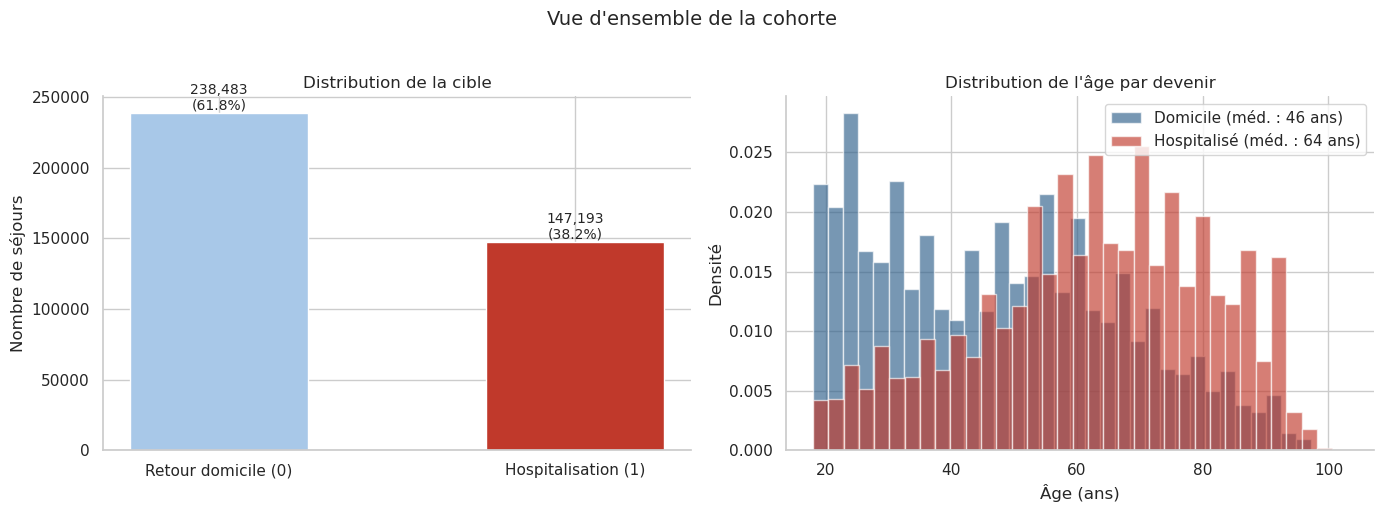

In [20]:
# Distribution de la cible
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

vals = cohort[TARGET].value_counts().sort_index()
labels = ['Retour domicile (0)', 'Hospitalisation (1)']
axes[0].bar(labels, vals.values, color=[BLEU_C, ROUGE], edgecolor='white', width=0.5)
axes[0].set_title('Distribution de la cible', fontsize=12, fontweight='normal')
axes[0].set_ylabel('Nombre de séjours')
for i, v in enumerate(vals.values):
    axes[0].text(i, v + max(vals)*0.01, f'{v:,}\n({v/len(cohort)*100:.1f}%)',
                 ha='center', fontsize=10, fontweight='normal')

# Distribution de l'âge par cible
AGE_COL = 'age_ed' if 'age_ed' in cohort.columns else 'anchor_age'
for tgt, color, label in [(0, BLEU, 'Domicile'), (1, ROUGE, 'Hospitalisé')]:
    data = cohort.loc[cohort[TARGET] == tgt, AGE_COL].dropna()
    axes[1].hist(data, bins=35, alpha=0.65, color=color, edgecolor='white',
                 density=True, label=f"{label} (méd. : {data.median():.0f} ans)")
axes[1].set_title("Distribution de l'âge par devenir", fontsize=12, fontweight='normal')
axes[1].set_xlabel('Âge (ans)')
axes[1].set_ylabel('Densité')
axes[1].legend()

plt.suptitle('Vue d\'ensemble de la cohorte', fontsize=14, fontweight='normal', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig1_cible_age.png', dpi=150, bbox_inches='tight')
plt.show()

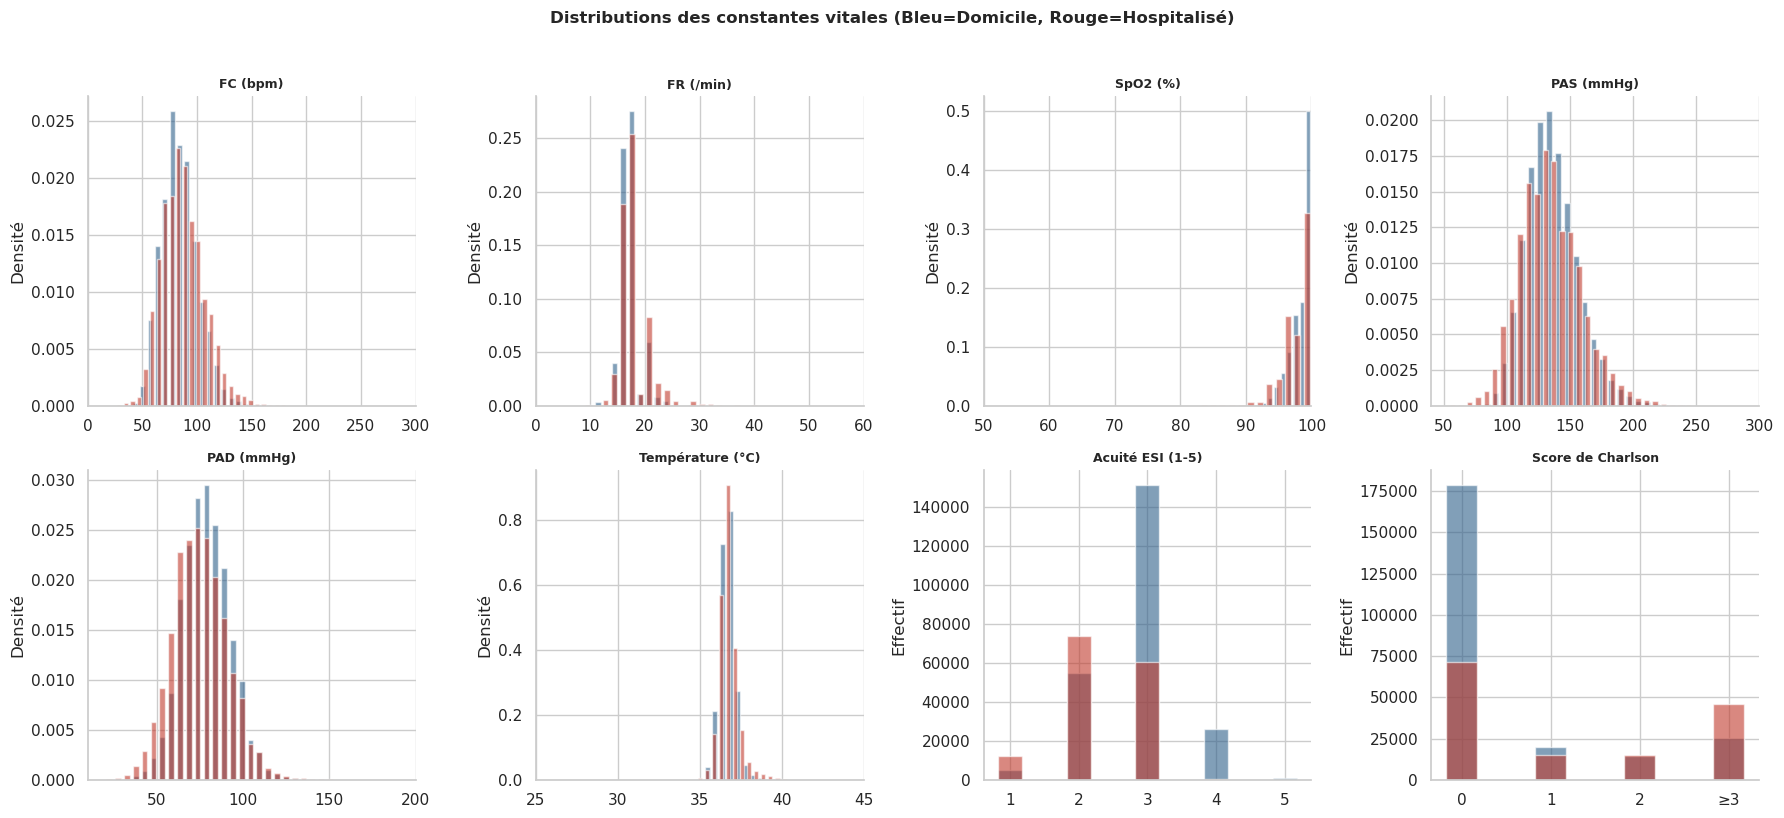

In [21]:
# Distributions des constantes vitales
CLIP_BOUNDS = {
    'heartrate':   (0,  300),
    'resprate':    (0,   60),
    'o2sat':       (50, 100),
    'sbp':         (40, 300),
    'dbp':         (10, 200),
    'temperature': (25,  45),
}

BAR_WIDTH = 0.35
HIST_RWIDTH = 0.65

vitals_config = [
    ('heartrate',      'FC (bpm)'),
    ('resprate',       'FR (/min)'),
    ('o2sat',          'SpO2 (%)'),
    ('sbp',            'PAS (mmHg)'),
    ('dbp',            'PAD (mmHg)'),
    ('temperature',    'Température (°C)'),
    ('acuity',         'Acuité ESI (1-5)'),
    ('charlson_score', 'Score de Charlson'),
]
vitals_config = [(c, l) for c, l in vitals_config if c in cohort.columns]

n_plots = len(vitals_config)
ncols   = 4
nrows   = (n_plots + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

for ax, (col, label) in zip(axes, vitals_config):
    lo, hi = CLIP_BOUNDS.get(col, (cohort[col].min(), cohort[col].max()))

    if col == 'acuity':
        vals = [1, 2, 3, 4, 5]
        for tgt, color, alpha in [(0, BLEU, 0.6), (1, ROUGE, 0.6)]:
            counts = [
                cohort.loc[(cohort[TARGET] == tgt) &
                           (cohort[col].round() == v), col].count()
                for v in vals
            ]
            ax.bar(vals, counts, color=color, edgecolor='white',
                   alpha=alpha, width=BAR_WIDTH)
        ax.set_xticks(vals)
        ax.set_xticklabels(['1', '2', '3', '4', '5'])
        ax.set_ylabel('Effectif')

    elif col in ['charlson_score', 'charlson_score_simplifie']:
        bins_charlson = [0, 1, 2, 3, float('inf')]
        labels_ch     = ['0', '1', '2', '≥3']
        cohort['_ch_cat'] = pd.cut(
            cohort[col], bins=bins_charlson,
            labels=labels_ch, right=False
        )
        for tgt, color, alpha in [(0, BLEU, 0.6), (1, ROUGE, 0.6)]:
            counts = [
                cohort.loc[cohort[TARGET] == tgt, '_ch_cat']
                      .value_counts().get(lbl, 0)
                for lbl in labels_ch
            ]
            ax.bar(range(len(labels_ch)), counts,
                   color=color, edgecolor='white', alpha=alpha, width=BAR_WIDTH)
        ax.set_xticks(range(len(labels_ch)))
        ax.set_xticklabels(labels_ch)
        ax.set_ylabel('Effectif')
        cohort.drop(columns=['_ch_cat'], inplace=True, errors='ignore')

    else:
        for tgt, color, alpha in [(0, BLEU, 0.6), (1, ROUGE, 0.6)]:
            d = cohort.loc[cohort[TARGET] == tgt, col].clip(lo, hi).dropna()
            ax.hist(d, bins=35, alpha=alpha, color=color,
                    edgecolor='white', density=True, rwidth=HIST_RWIDTH)
        ax.set_xlim(lo, hi)
        ax.set_ylabel('Densité')

    ax.set_title(label, fontsize=9, fontweight='bold')

for ax in axes[len(vitals_config):]:
    ax.axis('off')

plt.suptitle('Distributions des constantes vitales (Bleu=Domicile, Rouge=Hospitalisé)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig2_constantes_vitales.png', dpi=150, bbox_inches='tight')
plt.show()

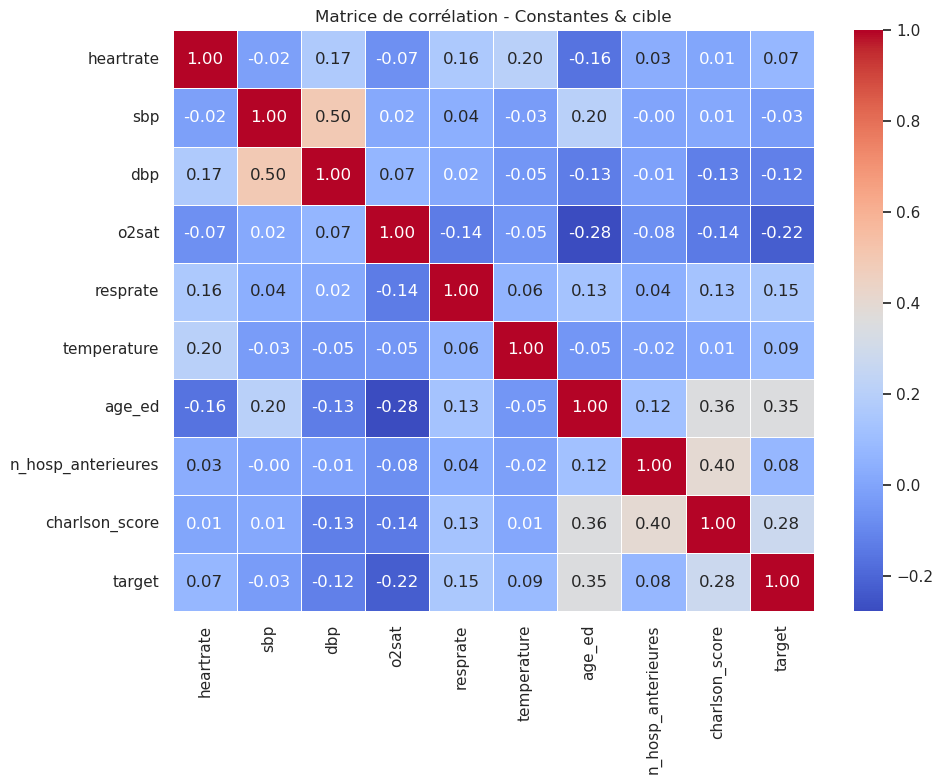

In [22]:
# Matrice de corrélation
plt.figure(figsize=(10, 8))
AGE_COL = 'age_ed' if 'age_ed' in cohort.columns else 'anchor_age'
CHARLSON_COL = 'charlson_score' if 'charlson_score' in cohort.columns else 'charlson_score_simplifie'
cols_num = [c for c in cols_vitales + [AGE_COL,'n_hosp_anterieures',CHARLSON_COL, TARGET] if c in cohort.columns]
correlation = cohort[cols_num].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matrice de corrélation - Constantes & cible', fontsize=12, fontweight='normal')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig3_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

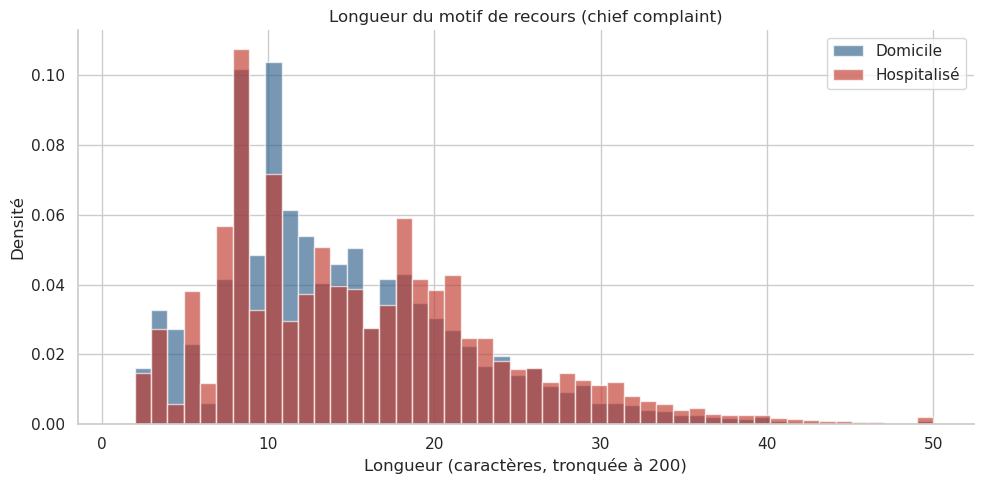

Longueur médiane — Domicile      : 12 car.
Longueur médiane — Hospitalisé   : 14 car.


,chiefcomplaint,target
0,"Abd pain, Abdominal distention",1
1,Abdominal distention,1
2,"n/v/d, Abd pain",1
3,Hypotension,0
4,"Abdominal distention, Abd pain, LETHAGIC",1


In [23]:
# Analyse du chief complaint
cohort['complaint_len'] = cohort['chiefcomplaint'].str.len()

fig, ax = plt.subplots(figsize=(10, 5))
for tgt, color, label in [(0, BLEU, 'Domicile'), (1, ROUGE, 'Hospitalisé')]:
    data = cohort.loc[cohort[TARGET] == tgt, 'complaint_len'].dropna()
    ax.hist(data.clip(0, 50), bins=50, alpha=0.65, color=color,
            edgecolor='white', density=True, label=label)
ax.set_title('Longueur du motif de recours (chief complaint)', fontsize=12, fontweight='normal')
ax.set_xlabel('Longueur (caractères, tronquée à 200)')
ax.set_ylabel('Densité')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig4_longueur_complaint.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Longueur médiane — Domicile      : {cohort.loc[cohort[TARGET]==0, "complaint_len"].median():.0f} car.')
print(f'Longueur médiane — Hospitalisé   : {cohort.loc[cohort[TARGET]==1, "complaint_len"].median():.0f} car.')
display(cohort[['chiefcomplaint', TARGET]].head(5)) if 'chiefcomplaint' in cohort.columns else display(cohort[[TARGET]].head(5))

In [24]:
!pip install -q spacy
!python -m spacy download en_core_web_sm -q
print("Installation terminée.")

[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
Installation terminée.


In [25]:
try:
    import spacy
    # Désactivation des composants non nécessaires pour accélérer le traitement
    nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])
    print(f'SpaCy {spacy.__version__} chargé - modèle : en_core_web_sm')
except OSError:
    raise OSError(
        'Modèle SpaCy absent. Lancer dans un terminal :\n'
        '  python -m spacy download en_core_web_sm'
    )

SpaCy 3.8.14 chargé - modèle : en_core_web_sm


In [26]:
# Guard spaCy
if 'SPACY_OK' not in dir():
    try:
        import spacy
        NLP = spacy.load('en_core_web_sm', disable=['parser', 'ner'])
        SPACY_OK = True
    except Exception:
        NLP, SPACY_OK = None, False
        print('⚠ SpaCy non disponible — lemmatisation désactivée')

# ── Dictionnaire abréviations médicales (ordre important : n/v/d avant n/v) ──
MEDICAL_ABBREV = {
    r'\bn\s*/\s*v\s*/\s*d\b': 'nausea vomiting diarrhea',
    r'\bnvd\b':                  'nausea vomiting diarrhea',
    r'\bn\s*/\s*v\b':           'nausea vomiting',
    r'\bsob\b':                  'shortness breath',
    r'\bcp\b':                   'chest pain',
    r'\babd\b':                  'abdominal',
    r'\bams\b':                  'altered mental status',
    r'\betoh\b':                 'alcohol',
    r'\buti\b':                  'urinary tract infection',
    r'\bdob\b':                  'difficulty breathing',
    r'\bha\b':                   'headache',
    r'\bcva\b':                  'stroke',
    r'\bhtn\b':                  'hypertension',
    r'\bdm\b':                   'diabetes',
    r'\bdvt\b':                  'deep vein thrombosis',
}

# Négations médicales à conserver (chest pain ≠ no chest pain)
NEGATIONS = {'no', 'not', 'without', 'denies', 'denied'}

def preprocess_medical_text(text: str) -> str:
    """
    Pipeline NLP MIMIC-IV ED :
    1. Expansion des abréviations médicales (n/v/d avant n/v)
    2. Mise en minuscule
    3. Conservation des chiffres (pain 10/10, o2 85, gcs 3)
    4. Lemmatisation SpaCy
    5. Conservation des négations (no, not, without, denies)
    6. Suppression stop-words sauf négations, tokens > 1 caractère
    """
    if not isinstance(text, str) or not text.strip():
        return ''

    text = text.lower()

    # Expansion des abréviations AVANT suppression des caractères
    for pattern, replacement in MEDICAL_ABBREV.items():
        text = re.sub(pattern, replacement, text)

    # Garder lettres + chiffres + espaces (correction : on ne supprime plus les chiffres)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    if SPACY_OK and NLP:
        doc = NLP(text)
        tokens = [
            token.lemma_
            for token in doc
            if (not token.is_stop or token.text.lower() in NEGATIONS)
            and len(token.text) > 1
        ]
        return ' '.join(tokens)
    return text

#  Tests 
tests = [
    ('SOB and CP x 2 hours',           'abréviations'),
    ('N/V/D, abd pain, fever',          'n/v/d'),
    ('no chest pain, denies SOB',       'négations'),
    ('pain 10/10, o2 85, fall 10 feet', 'chiffres conservés'),
    ('AMS, ETOH intoxication',          'abréviations 2'),
]
print('=== Tests du pipeline NLP ==')
for t, label in tests:
    print(f'[{label}]')
    print(f'Avant : {t}')
    print(f'Après : {preprocess_medical_text(t)}')
    print()

=== Tests du pipeline NLP ==
[abréviations]
Avant : SOB and CP x 2 hours
Après : shortness breath chest pain hour

[n/v/d]
Avant : N/V/D, abd pain, fever
Après : nausea vomit diarrhea abdominal pain fever

[négations]
Avant : no chest pain, denies SOB
Après : no chest pain deny shortness breath

[chiffres conservés]
Avant : pain 10/10, o2 85, fall 10 feet
Après : pain 10 10 o2 85 fall 10 foot

[abréviations 2]
Avant : AMS, ETOH intoxication
Après : alter mental status alcohol intoxication



In [27]:
print(f'Lancement du prétraitement NLP sur {len(df):,} séjours...')

df['cleaned_complaint'] = df['chiefcomplaint'].fillna('').apply(preprocess_medical_text)

# Suppression des lignes dont le texte est vide après nettoyage
n_avant = len(df)
df = df[df['cleaned_complaint'].str.strip() != ''].copy()

print(f'Prétraitement terminé')
print(f'Séjours avant nettoyage : {n_avant:,}')
print(f'Séjours après nettoyage : {len(df):,}  (retirés : {n_avant - len(df):,})')

display(df[['chiefcomplaint', 'cleaned_complaint', TARGET]].head(5))
#  Mise à jour du flowchart 
add_flow('chiefcomplaint exploitable après NLP', df)
print(f'[4] Motif exploitable après NLP : {len(df):,}  (retirés : {n_avant - len(df):,})')

# ── Recréation de cohort complet post-NLP 
# chiefcomplaint utilisée pour le NLP mais NON exportée dans cohort_raw
# seul cleaned_complaint est conservé
df_reset = df.reset_index(drop=True)
colonnes_sans_chief = [c for c in colonnes_provisoires if c != 'chiefcomplaint']
cohort = df_reset[colonnes_sans_chief].copy()
cohort['cleaned_complaint'] = df_reset['cleaned_complaint'].values
print(f'\nCohorte finale : {cohort.shape[0]:,} séjours × {cohort.shape[1]} colonnes')
assert 'cleaned_complaint' in cohort.columns, "ERREUR : cleaned_complaint absente de cohort !"
assert 'chiefcomplaint' not in cohort.columns, "ERREUR : chiefcomplaint encore présente — à supprimer"
print('cleaned_complaint intégrée dans cohort')
display(cohort[['cleaned_complaint', TARGET]].head(3))


Lancement du prétraitement NLP sur 385,676 séjours...
Prétraitement terminé
Séjours avant nettoyage : 385,676
Séjours après nettoyage : 383,919  (retirés : 1,757)


,chiefcomplaint,cleaned_complaint,target
0,"Abd pain, Abdominal distention",abdominal pain abdominal distention,1
1,Abdominal distention,abdominal distention,1
2,"n/v/d, Abd pain",nausea vomit diarrhea abdominal pain,1
3,Hypotension,hypotension,0
4,"Abdominal distention, Abd pain, LETHAGIC",abdominal distention abdominal pain lethagic,1


[4] Motif exploitable après NLP : 383,919  (retirés : 1,757)

Cohorte finale : 383,919 séjours × 38 colonnes
cleaned_complaint intégrée dans cohort


,cleaned_complaint,target
0,abdominal pain abdominal distention,1
1,abdominal distention,1
2,nausea vomit diarrhea abdominal pain,1


In [28]:
# Tableau de complétude des variables cliniques et contextuelles
cols_check = [c for c in cols_vitales + cols_contexte if c in cohort.columns]

completude = (
    cohort[cols_check]
    .notna()
    .mean()
    .mul(100)
    .round(1)
    .reset_index()
)
completude.columns = ["Variable", "Complétude (%)"]
completude = completude.sort_values("Complétude (%)", ascending=False)
display(completude)

,Variable,Complétude (%)
8,arrival_transport,100.0
9,hour,100.0
10,day_of_week,100.0
7,n_hosp_anterieures,100.0
0,heartrate,99.7
1,sbp,99.3
2,dbp,99.1
4,resprate,98.9
3,o2sat,98.8
5,temperature,98.1


---
## 9. Flowchart final

,etape,n,n_exclus
0,Séjours ED initiaux (ADMITTED+HOME),399642,0
1,Adultes ≥ 18 ans (age_ed),399573,69
2,≥ 1 constante vitale au triage,385679,13894
3,chiefcomplaint renseigné,385676,3
4,chiefcomplaint exploitable après NLP,383919,1757


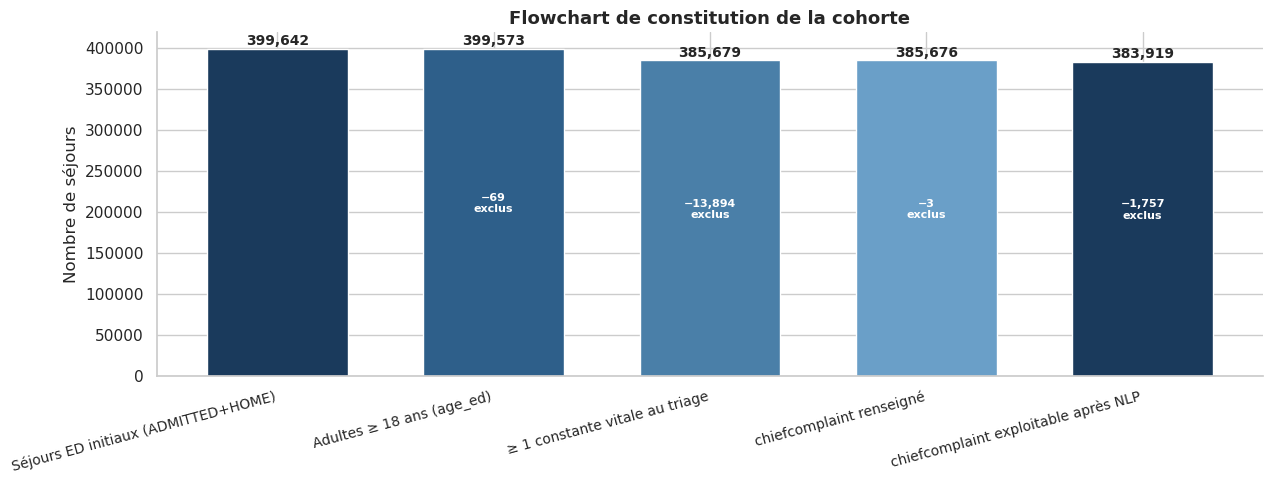

Flowchart sauvegardé → results/tables/tab1_flowchart_cohorte.csv


In [29]:
flow_df = pd.DataFrame(flow)
flow_df['n_exclus'] = (flow_df['n'].shift(1).fillna(flow_df['n']).astype(int)
                       - flow_df['n'].astype(int))

display(flow_df)

fig, ax = plt.subplots(figsize=(13, 5))
colors = ['#1A3A5C', '#2E5F8A', '#4A7FA8', '#6A9FC8']
labels = flow_df['etape'].tolist()
values = flow_df['n'].tolist()
exclus = flow_df['n_exclus'].fillna(0).astype(int).tolist()

bars = ax.bar(range(len(labels)), values,
              color=colors[:len(labels)], edgecolor='white', width=0.65)
for i, (val, excl) in enumerate(zip(values, exclus)):
    ax.text(i, val + max(values)*0.01, f'{val:,}',
            ha='center', fontsize=10, fontweight='bold')
    if excl > 0:
        ax.text(i, val / 2, f'−{excl:,}\nexclus',
                ha='center', fontsize=8, color='white', fontweight='bold')

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=15, ha='right', fontsize=10)
ax.set_ylabel('Nombre de séjours')
ax.set_title('Flowchart de constitution de la cohorte', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig5_flowchart_barres.png', dpi=150, bbox_inches='tight')
plt.show()

# Sauvegarde CSV du flowchart
flow_df.to_csv(RESULT_DIR / 'tables' / 'tab1_flowchart_cohorte.csv', index=False)
print('Flowchart sauvegardé → results/tables/tab1_flowchart_cohorte.csv')

---
## 10. Sauvegarde OBLIGATOIRE pour les notebooks suivants

In [30]:
# Supprimer la colonne temporaire de longueur (feature de travail, pas une feature métier)
if 'complaint_len' in cohort.columns:
    cohort = cohort.drop(columns=['complaint_len'])

#  Vérification NLP avant sauvegarde 
assert 'cleaned_complaint' in cohort.columns, \
    "ERREUR : cleaned_complaint absente — vérifier que le NLP (cell 31) a bien été exécuté"
print(f'cleaned_complaint présente : {cohort["cleaned_complaint"].notna().sum():,} valeurs')

#  Sauvegarde principale de la cohorte 
out_path = OUT_DIR / 'cohort_raw.csv'
cohort.to_csv(out_path, index=False)
print(f'cohort_raw.csv sauvegardé : {len(cohort):,} lignes × {cohort.shape[1]} colonnes')
print(f'Colonnes : {list(cohort.columns)}')

#  Métadonnées pour traçabilité (cohort_meta.json) 
meta = {
    'target': TARGET,
    'n_total': int(len(cohort)),
    'n_positif': int(cohort[TARGET].sum()),
    'prevalence': float(cohort[TARGET].mean()),
    'cols_cliniques': cols_vitales,
    'cols_context': cols_contexte,
    'cols_texte': ['cleaned_complaint'],  # chiefcomplaint exclue de cohort_raw (v2)
    'random_state': RANDOM_STATE,
}
with open(OUT_DIR / 'splits' / 'cohort_meta.json', 'w', encoding='utf-8') as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)

print("\n cohort_meta.json sauvegardé → data/processed/splits/")

cleaned_complaint présente : 383,919 valeurs
cohort_raw.csv sauvegardé : 383,919 lignes × 38 colonnes
Colonnes : ['subject_id', 'stay_id', 'intime', 'anchor_year_group', 'ayg_start', 'anchor_year', 'intime_year', 'target', 'acuity', 'heartrate', 'sbp', 'dbp', 'o2sat', 'resprate', 'temperature', 'age_ed', 'anchor_age', 'gender', 'pain', 'n_hosp_anterieures', 'arrival_transport', 'hour', 'day_of_week', 'charlson_score_simplifie', 'charlson_score', 'cm_dm_sans_complic', 'cm_dm_avec_complic', 'cm_insuffisance_card', 'cm_bpco', 'cm_insuffisance_renale', 'cm_cancer', 'cm_cancer_meta', 'cm_infarctus', 'cm_avc', 'cm_demence', 'cm_maladie_foie', 'cm_vih_sida', 'cleaned_complaint']

 cohort_meta.json sauvegardé → data/processed/splits/


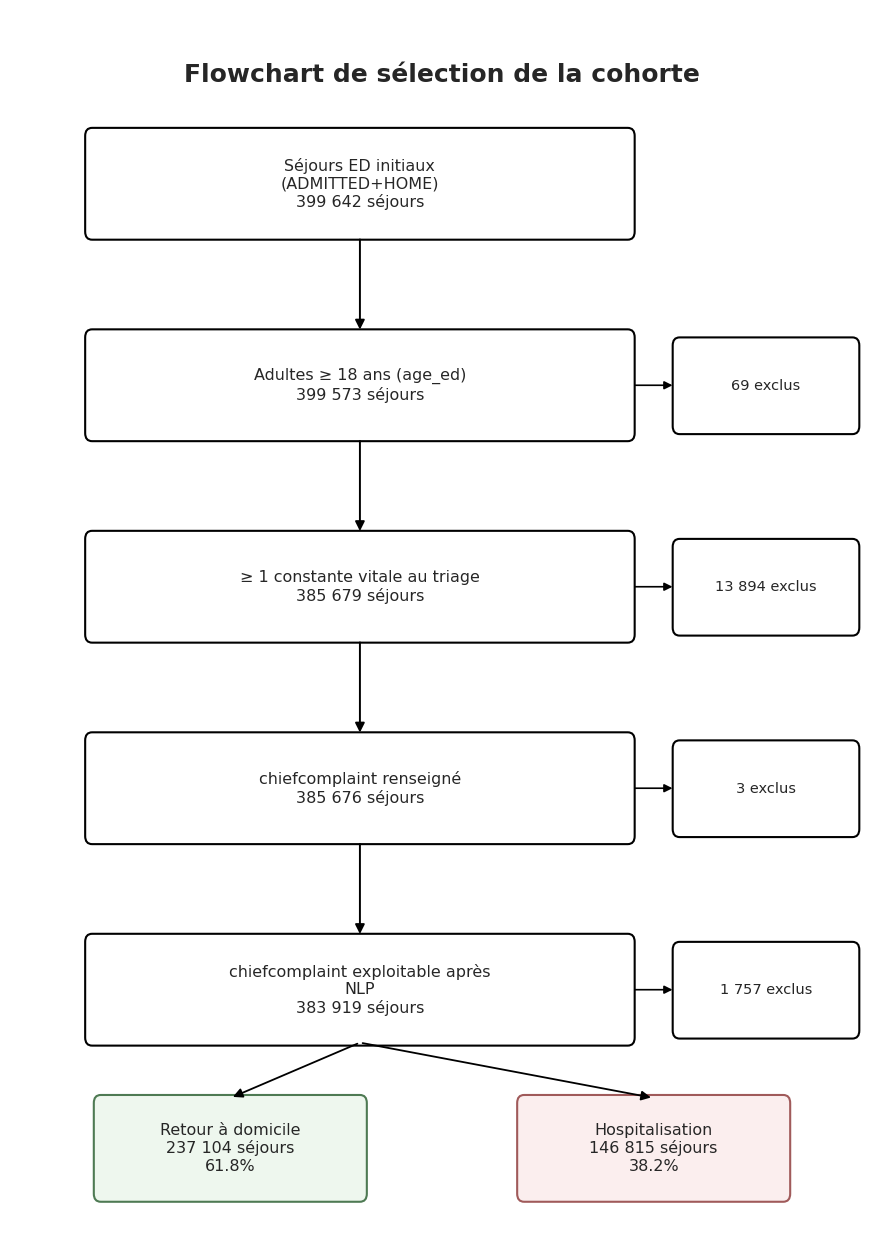

In [31]:
# Construction du charte flow.
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from pathlib import Path
import textwrap

# FIG_DIR déjà défini par le bloc chemins unifié (ne pas redéfinir en relatif).
FIG_DIR.mkdir(parents=True, exist_ok=True)
out_path = FIG_DIR / "fig6_flowchart.png"

# Flowchart dynamique : les effectifs proviennent de flow_df et de cohort.
if 'flow_df' not in globals():
    flow_df = pd.DataFrame(flow)
if 'n_exclus' not in flow_df.columns:
    flow_df = flow_df.copy()
    flow_df['n_exclus'] = (
        flow_df['n'].shift(1).fillna(flow_df['n']).astype(int)
        - flow_df['n'].astype(int)
    )

n_home = int((cohort[TARGET] == 0).sum())
n_hosp = int((cohort[TARGET] == 1).sum())
n_total = int(len(cohort))

main_x, main_w, main_h = 0.9, 6.3, 1.05
side_x, side_w, side_h = 7.7, 2.1, 0.90

# Positions verticales des étapes (calculées avant le titre et set_ylim)
y_positions = list(reversed([1.9 + 2.0*i for i in range(len(flow_df))]))
y_top = y_positions[0] + main_h

fig, ax = plt.subplots(figsize=(9, 1.8 * (len(flow_df) + 2)))
ax.set_xlim(0, 10)
ax.set_ylim(0, y_top + 1.2)
ax.axis("off")

def wrap(txt, width=32):
    return "\n".join(textwrap.wrap(str(txt), width=width))

def box(x, y, w, h, text, fontsize=11.5, lw=1.5, edgecolor="black", facecolor="white"):
    rect = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.03,rounding_size=0.08",
        linewidth=lw,
        edgecolor=edgecolor,
        facecolor=facecolor
    )
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, text, ha="center", va="center",
            fontsize=fontsize, multialignment="center")
    return rect

def arrow(x1, y1, x2, y2, lw=1.4, ms=14):
    ax.add_patch(FancyArrowPatch(
        (x1, y1), (x2, y2),
        arrowstyle="-|>",
        mutation_scale=ms,
        linewidth=lw,
        color="black"
    ))

ax.text(
    5, y_top + 0.55,
    "Flowchart de sélection de la cohorte",
    ha="center", va="center", fontsize=18, fontweight="bold"
)

main_x, main_w, main_h = 0.9, 6.3, 1.05
side_x, side_w, side_h = 7.7, 2.1, 0.90
# Étapes principales
for (idx, row), y in zip(flow_df.iterrows(), y_positions):
    label = f"{wrap(row['etape'])}\n{int(row['n']):,} séjours".replace(",", " ")
    box(main_x, y, main_w, main_h, label)
# Exclusions latérales à partir de la deuxième étape
for k, ((idx, row), y) in enumerate(zip(flow_df.iterrows(), y_positions)):
    n_excl = int(row.get('n_exclus', 0))
    if k > 0 and n_excl > 0:
        txt = f"{n_excl:,} exclus".replace(",", " ")
        box(side_x, y + 0.07, side_w, side_h, txt, fontsize=10.5)
        arrow(main_x + main_w, y + main_h/2, side_x, y + main_h/2, lw=1.2, ms=12)
# Flèches principales
for y1, y2 in zip(y_positions[:-1], y_positions[1:]):
    arrow(main_x + main_w/2, y1, main_x + main_w/2, y2 + main_h)
# Cases finales selon target
bottom_y = 0.35
final_w, final_h = 3.1, 1.0
left_x, right_x = 1.0, 5.9
box(left_x, bottom_y, final_w, final_h,
    f"Retour à domicile\n{n_home:,} séjours\n{n_home/n_total:.1%}".replace(",", " "),
    fontsize=11.5, edgecolor="#4E7A53", facecolor="#EEF7EE")
box(right_x, bottom_y, final_w, final_h,
    f"Hospitalisation\n{n_hosp:,} séjours\n{n_hosp/n_total:.1%}".replace(",", " "),
    fontsize=11.5, edgecolor="#A05A5A", facecolor="#FBEEEE")
# Flèches depuis la dernière étape
last_y = y_positions[-1]
x_center = main_x + main_w/2
arrow(x_center, last_y, left_x + final_w/2, bottom_y + final_h, lw=1.3, ms=14)
arrow(x_center, last_y, right_x + final_w/2, bottom_y + final_h, lw=1.3, ms=14)

plt.tight_layout()
fig.savefig(out_path, dpi=250, bbox_inches="tight")
plt.show()
#print(f"Figure enregistrée ici : {out_path.resolve()}")

In [32]:
print('=' * 60)
print('RÉSUMÉ FINAL — Notebook 01')
print('=' * 60)
print(f'  Cohorte finale        : {len(cohort):,} séjours')
print(f'  Patients uniques      : {cohort["subject_id"].nunique():,}')
print(f'  Hospitalisés (target=1): {cohort[TARGET].sum():,} ({cohort[TARGET].mean()*100:.1f}%)')
print(f'  Retour domicile       : {(cohort[TARGET]==0).sum():,} ({(cohort[TARGET]==0).mean()*100:.1f}%)')
#print()
#print('Fichiers sauvegardés :')
#print(f'  {OUT_DIR}/cohort_raw.csv')              
#print(f'  {OUT_DIR}/splits/cohort_meta.json')        
#print(f'  {RESULT_DIR}/tables/tab1_flowchart_cohorte.csv')
print()
print('Figures générées :')
print('  fig1 : Distribution cible & age')
print('  fig2 : Constantes vitales')
print('  fig3 : Matrice de correlation')
print('  fig4 : Longueur du motif de recours')
print('  fig5 : Flowchart (barres)')
print('  fig6 : Flowchart (diagramme)')
print()

RÉSUMÉ FINAL — Notebook 01
  Cohorte finale        : 383,919 séjours
  Patients uniques      : 188,127
  Hospitalisés (target=1): 146,815 (38.2%)
  Retour domicile       : 237,104 (61.8%)

Figures générées :
  fig1 : Distribution cible & age
  fig2 : Constantes vitales
  fig3 : Matrice de correlation
  fig4 : Longueur du motif de recours
  fig5 : Flowchart (barres)
  fig6 : Flowchart (diagramme)



In [33]:
print("NB01 terminé")


NB01 terminé
